In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
)

# Reproducibility
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)


In [ ]:
train_df = pd.read_csv("/content/sample_data/train_dataset.csv")
test_df = pd.read_csv("/content/sample_data/test_dataset.csv")

In [ ]:
train_df.head()

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
0,33.09,3.68,357.75,19.87,383.79,63.024
1,76.30,1.34,429.70,14.84,405.72,86.611
2,59.90,1.01,431.10,11.76,385.40,86.347
3,49.90,2.21,445.61,22.85,367.74,92.175
4,16.70,3.95,458.91,4.56,374.13,82.211


In [ ]:
test_df.head()

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K
0,43.73,2.88,454.18,7.66,440.61
1,47.80,2.33,401.37,19.95,390.13
2,7.14,0.65,411.86,3.05,476.23
3,17.86,1.28,385.97,22.36,353.56
4,56.40,2.51,495.33,8.36,517.71


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   flow_rate_L_min       150 non-null    float64
 1   concentration_mol_L   150 non-null    float64
 2   inlet_temperature_K   150 non-null    float64
 3   length_m              150 non-null    float64
 4   jacket_temperature_K  150 non-null    float64
 5   overall_yield         150 non-null    float64
dtypes: float64(6)
memory usage: 7.2 KB


In [ ]:
train_df.describe()

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,40.466800,2.311333,424.423400,14.086533,442.240800,36.222173
std,22.239772,1.019844,45.200641,6.995343,55.047768,38.427427
min,5.410000,0.520000,351.630000,2.260000,354.010000,0.000000
25%,21.112500,1.362500,387.255000,8.027500,393.327500,0.013500
50%,38.610000,2.445000,425.630000,14.235000,437.080000,15.314000
75%,61.227500,3.155000,462.972500,20.685000,486.180000,74.876500
max,79.020000,3.970000,498.580000,24.990000,547.990000,99.971000


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   flow_rate_L_min       50 non-null     float64
 1   concentration_mol_L   50 non-null     float64
 2   inlet_temperature_K   50 non-null     float64
 3   length_m              50 non-null     float64
 4   jacket_temperature_K  50 non-null     float64
dtypes: float64(5)
memory usage: 2.1 KB


In [ ]:
print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in test data:")
print(test_df.isnull().sum())

Missing values in training data:
flow_rate_L_min         0
concentration_mol_L     0
inlet_temperature_K     0
length_m                0
jacket_temperature_K    0
overall_yield           0
dtype: int64

Missing values in test data:
flow_rate_L_min         0
concentration_mol_L     0
inlet_temperature_K     0
length_m                0
jacket_temperature_K    0
dtype: int64


In [ ]:
print("Duplicate rows in training:", train_df.duplicated().sum())
print("Duplicate rows in test:", test_df.duplicated().sum())

Duplicate rows in training: 0
Duplicate rows in test: 0


In [ ]:
features = [
    "flow_rate_L_min",
    "concentration_mol_L",
    "inlet_temperature_K",
    "length_m",
    "jacket_temperature_K"
]

target = "overall_yield"

X_train = train_df[features]
Y_train = train_df[target]

X_test = test_df[features]

In [ ]:
X_train.shape

(150, 5)

In [ ]:
Y_train.shape

(150,)

In [ ]:
X_test.shape

(50, 5)

In [ ]:
Y_train.describe()

,overall_yield
count,150.000000
mean,36.222173
std,38.427427
min,0.000000
25%,0.013500
50%,15.314000
75%,74.876500
max,99.971000


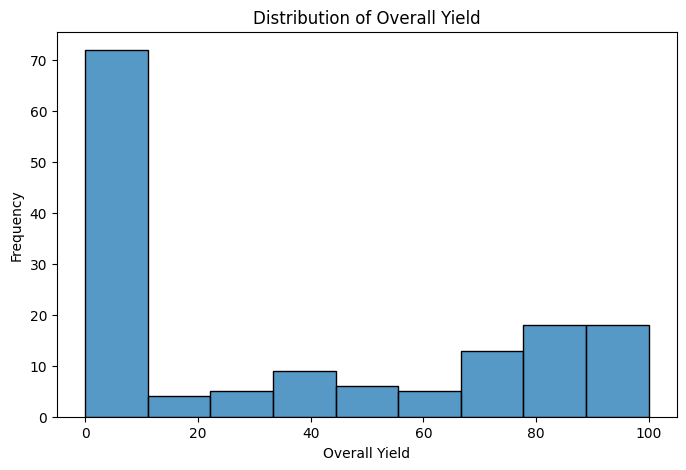

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(Y_train)

plt.xlabel("Overall Yield")
plt.ylabel("Frequency")
plt.title("Distribution of Overall Yield")

plt.show()

In [ ]:
X_train.describe()

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,40.466800,2.311333,424.423400,14.086533,442.240800
std,22.239772,1.019844,45.200641,6.995343,55.047768
min,5.410000,0.520000,351.630000,2.260000,354.010000
25%,21.112500,1.362500,387.255000,8.027500,393.327500
50%,38.610000,2.445000,425.630000,14.235000,437.080000
75%,61.227500,3.155000,462.972500,20.685000,486.180000
max,79.020000,3.970000,498.580000,24.990000,547.990000


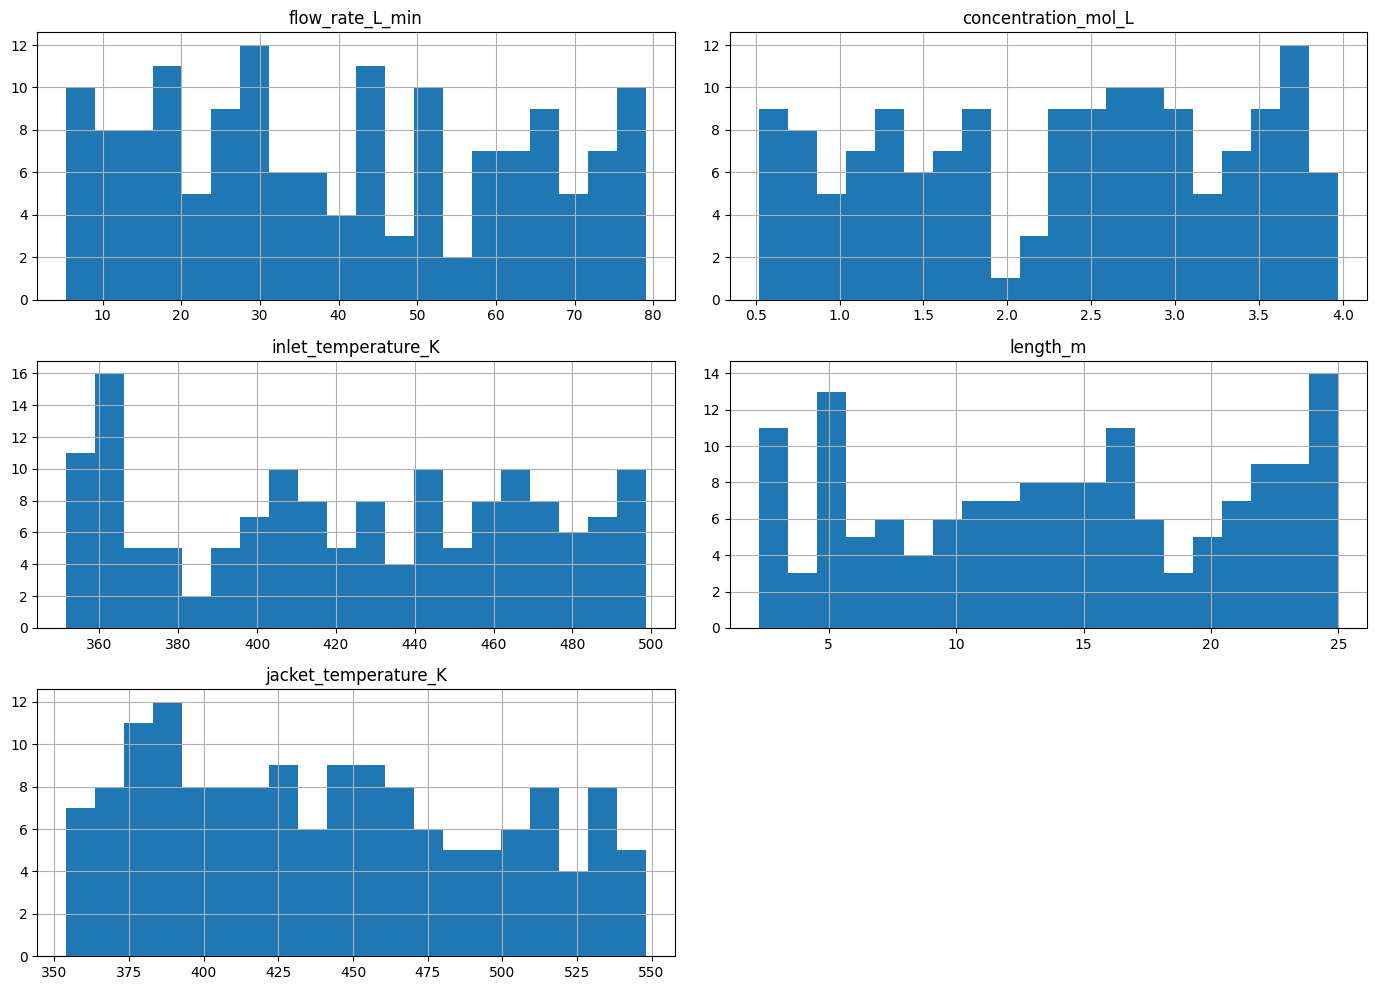

In [ ]:
X_train.hist(
    figsize=(14, 10),
    bins=20
)

plt.tight_layout()
plt.show()

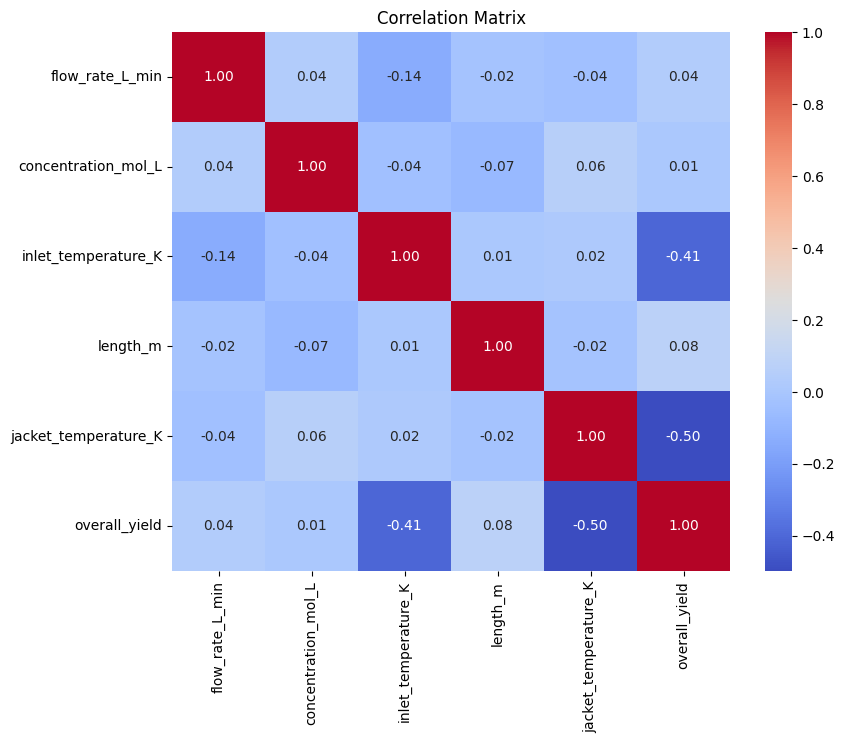

In [ ]:
plt.figure(figsize=(9, 7))

cm = train_df[features + [target]].corr()

sns.heatmap(
    cm,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

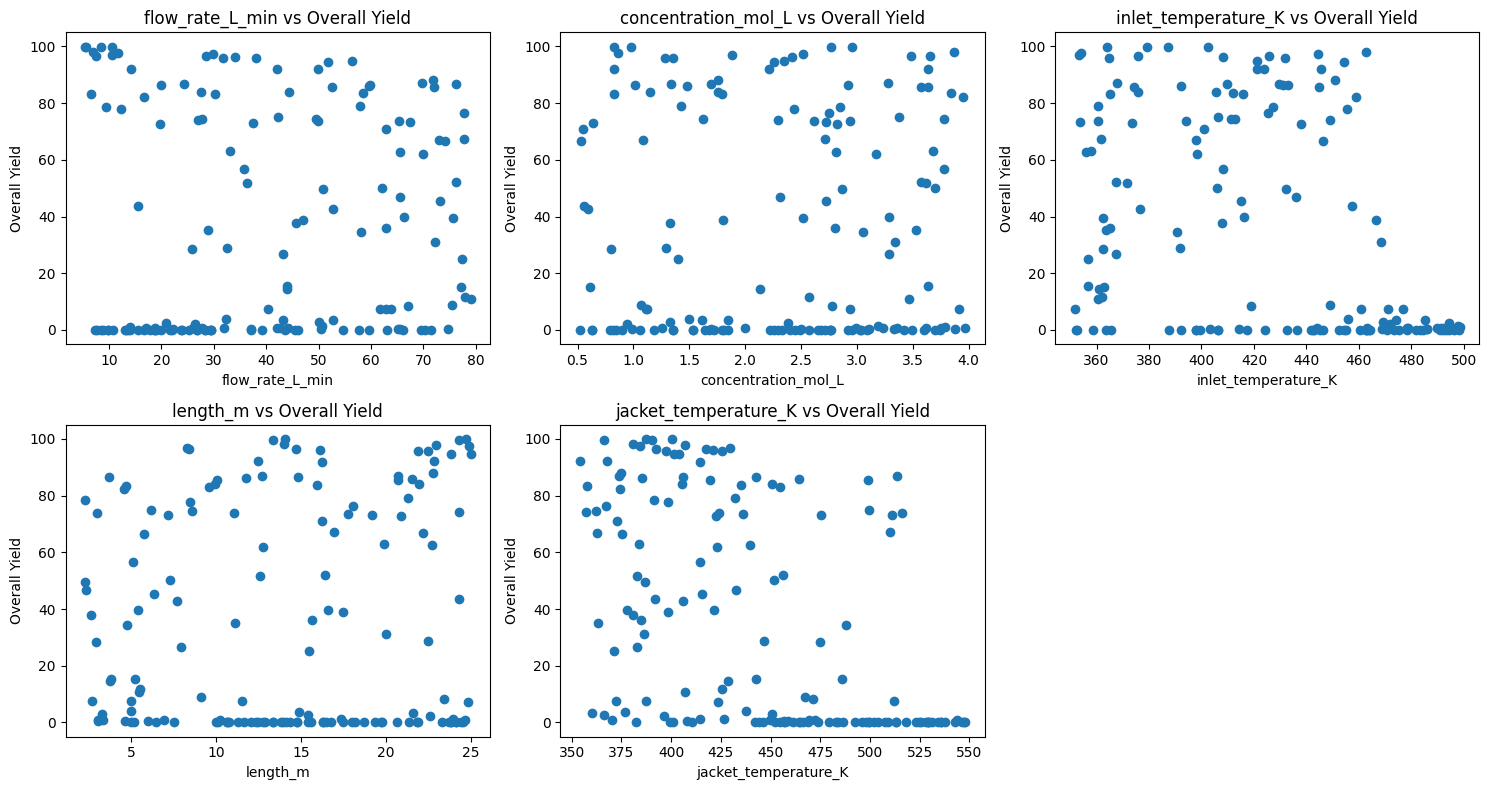

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, feature in enumerate(features):
    row = i // 3
    col = i % 3

    axes[row, col].scatter(
        train_df[feature],
        train_df[target]
    )

    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel("Overall Yield")
    axes[row, col].set_title(f"{feature} vs Overall Yield")


axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    Y_train,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training samples:", X_train_split.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 120
Validation samples: 30


In [ ]:
model_lr = LinearRegression()

model_lr.fit(
    X_train_split,
    y_train_split
)

y_pred_lr = model_lr.predict(X_val)

rmse_lr = np.sqrt(
    mean_squared_error(y_val, y_pred_lr)
)

print("Linear Regression RMSE:", rmse_lr)

Linear Regression RMSE: 31.423627067386263


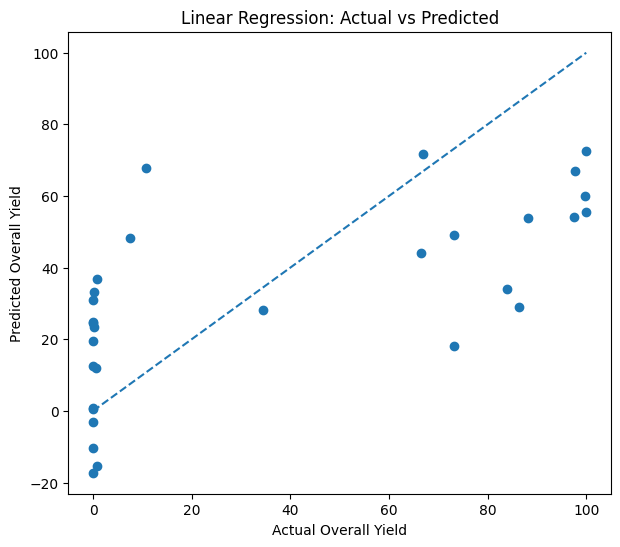

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(y_val, y_pred_lr)

plt.xlabel("Actual Overall Yield")
plt.ylabel("Predicted Overall Yield")
plt.title("Linear Regression: Actual vs Predicted")

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--"
)

plt.show()

In [ ]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scores = cross_val_score(
    LinearRegression(),
    X_train,
    Y_train,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

cv_rmse = -cv_scores

print("RMSE for each fold:")
print(cv_rmse)

print("\nMean CV RMSE:", cv_rmse.mean())
print("Std CV RMSE:", cv_rmse.std())

RMSE for each fold:
[31.42362707 32.1876023  28.09056256 28.9437805  31.18622067]

Mean CV RMSE: 30.36635862034882
Std CV RMSE: 1.5690694748844813


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    max_features=1.0
)

rf_model.fit(
    X_train_split,
    y_train_split
)

y_pred_rf = rf_model.predict(X_val)

rmse_rf = np.sqrt(
    mean_squared_error(y_val, y_pred_rf)
)

print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 21.493927930310157


In [ ]:
rf_cv_scores = cross_val_score(
    RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        max_features=1.0
    ),
    X_train,
    Y_train,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

rf_cv_rmse = -rf_cv_scores

print("Random Forest RMSE for each fold:")
print(rf_cv_rmse)

print("\nMean CV RMSE:", rf_cv_rmse.mean())
print("Std CV RMSE:", rf_cv_rmse.std())

Random Forest RMSE for each fold:
[21.53843491 23.03503376 23.63872032 19.17912994 18.57940764]

Mean CV RMSE: 21.194145315170797
Std CV RMSE: 2.0189349966511085


In [ ]:
extra_model = ExtraTreesRegressor(
n_estimators=300,
random_state=RANDOM_STATE,
max_features=1.0
)
extra_model.fit(
X_train_split,
y_train_split
)
y_pred_extra = extra_model.predict(X_val)
rmse_extra = np.sqrt(
mean_squared_error(y_val, y_pred_extra)
)
print("Extra Trees RMSE:", rmse_extra)


Extra Trees RMSE: 19.585614983054743


In [ ]:
extra_cv_scores = cross_val_score(
    ExtraTreesRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        max_features=1.0
    ),
    X_train_split,
    y_train_split,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

extra_cv_rmse = -extra_cv_scores

print("Extra Trees RMSE for each fold:")
print(extra_cv_rmse)

print("\nMean CV RMSE:", extra_cv_rmse.mean())
print("Std CV RMSE:", extra_cv_rmse.std())

Extra Trees RMSE for each fold:
[23.26724999 22.66018682 20.43444218 20.91130799 15.68806612]

Mean CV RMSE: 20.59225061916809
Std CV RMSE: 2.6686966255569566


In [ ]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=2,
    random_state=RANDOM_STATE
)

gb_model.fit(
    X_train_split,
    y_train_split
)

y_pred_gb = gb_model.predict(X_val)

rmse_gb = np.sqrt(
    mean_squared_error(y_val, y_pred_gb)
)

print("Gradient Boosting RMSE:", rmse_gb)

Gradient Boosting RMSE: 24.858867016165863


In [ ]:
gb_cv_scores = cross_val_score(
    GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        random_state=RANDOM_STATE
    ),
    X_train,
    Y_train,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

gb_cv_rmse = -gb_cv_scores

print("Gradient Boosting RMSE for each fold:")
print(gb_cv_rmse)

print("\nMean CV RMSE:", gb_cv_rmse.mean())
print("Std CV RMSE:", gb_cv_rmse.std())

Gradient Boosting RMSE for each fold:
[24.85886702 28.13893465 28.66138779 27.93292649 25.48848236]

Mean CV RMSE: 27.016119661063932
Std CV RMSE: 1.5359407650535402


In [ ]:
extra_model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    max_features=1.0
)

extra_model.fit(
    X_train_split,
    y_train_split
)

ExtraTreesRegressor(n_estimators=300, random_state=42)

In [ ]:
feature_importance = pd.Series(
    extra_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(feature_importance)

inlet_temperature_K     0.349313
jacket_temperature_K    0.342315
flow_rate_L_min         0.135832
length_m                0.108411
concentration_mol_L     0.064129
dtype: float64


In [ ]:
y_pred_extra = extra_model.predict(X_val)

rmse_extra = np.sqrt(
    mean_squared_error(y_val, y_pred_extra)
)

print("Extra Trees Validation RMSE:", rmse_extra)

Extra Trees Validation RMSE: 19.585614983054743


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [None, 5, 8, 12, 16],
    "min_samples_split": [2, 3, 5, 8],
    "min_samples_leaf": [1, 2, 3, 4],
    "max_features": [1.0, "sqrt", 0.8]
}

In [ ]:
extra_search = RandomizedSearchCV(
    estimator=ExtraTreesRegressor(
        random_state=RANDOM_STATE
    ),
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

extra_search.fit(
    X_train_split,
    y_train_split
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=ExtraTreesRegressor(random_state=42), n_iter=30,
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 5, 8, 12, 16],
                                        'max_features': [1.0, 'sqrt', 0.8],
                                        'min_samples_leaf': [1, 2, 3, 4],
                                        'min_samples_split': [2, 3, 5, 8],
                                        'n_estimators': [200, 300, 500, 800]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [ ]:
print("Best CV RMSE:", -extra_search.best_score_)

print("\nBest Parameters:")
print(extra_search.best_params_)

Best CV RMSE: 20.502708467762865

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 12}


In [ ]:
best_extra_model = extra_search.best_estimator_

y_pred_tuned = best_extra_model.predict(X_val)

rmse_tuned = np.sqrt(
    mean_squared_error(y_val, y_pred_tuned)
)

print("Tuned Extra Trees Validation RMSE:", rmse_tuned)

Tuned Extra Trees Validation RMSE: 19.867691358227816


In [ ]:
baseline_extra_cv = cross_val_score(
    ExtraTreesRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        max_features=1.0
    ),
    X_train_split,
    y_train_split,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

baseline_extra_cv_rmse = -baseline_extra_cv

print("Baseline Extra Trees RMSE for each fold:")
print(baseline_extra_cv_rmse)

print("\nMean CV RMSE:", baseline_extra_cv_rmse.mean())
print("Std CV RMSE:", baseline_extra_cv_rmse.std())

Baseline Extra Trees RMSE for each fold:
[23.26724999 22.66018682 20.43444218 20.91130799 15.68806612]

Mean CV RMSE: 20.59225061916809
Std CV RMSE: 2.6686966255569566


In [ ]:
train_fe = X_train_split.copy()
val_fe = X_val.copy()

train_fe["temperature_difference_K"] = (
    train_fe["inlet_temperature_K"]
    - train_fe["jacket_temperature_K"]
)

val_fe["temperature_difference_K"] = (
    val_fe["inlet_temperature_K"]
    - val_fe["jacket_temperature_K"]
)

In [ ]:
train_fe.head()

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,temperature_difference_K
22,26.91,2.29,449.03,2.99,424.09,24.94
15,18.76,3.42,454.40,10.62,534.17,-79.77
65,45.70,1.33,407.92,2.61,380.57,27.35
11,77.74,2.71,361.77,16.93,509.88,-148.11
42,7.58,3.65,375.98,8.38,392.29,-16.31


In [ ]:
extra_fe_model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    max_features=1.0
)

extra_fe_model.fit(
    train_fe,
    y_train_split
)

ExtraTreesRegressor(n_estimators=300, random_state=42)

In [ ]:
y_pred_fe = extra_fe_model.predict(val_fe)

rmse_fe = np.sqrt(
    mean_squared_error(y_val, y_pred_fe)
)

print("Extra Trees with Temperature Difference RMSE:", rmse_fe)

Extra Trees with Temperature Difference RMSE: 19.51733235614612


In [ ]:
fe_cv_scores = cross_val_score(
    ExtraTreesRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        max_features=1.0
    ),
    train_fe,
    y_train_split,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

fe_cv_rmse = -fe_cv_scores

print("Feature-engineered Extra Trees RMSE for each fold:")
print(fe_cv_rmse)

print("\nMean CV RMSE:", fe_cv_rmse.mean())
print("Std CV RMSE:", fe_cv_rmse.std())

Feature-engineered Extra Trees RMSE for each fold:
[23.0501891  22.06955801 19.60267923 21.97170523 16.16783356]

Mean CV RMSE: 20.57239302526532
Std CV RMSE: 2.4770765014375447


Adding the temperature difference as a physically motivated derived feature produced a modest improvement in both cross-validation and holdout RMSE.

In [ ]:
train_fe["flow_length_ratio"] = (
    train_fe["flow_rate_L_min"] / train_fe["length_m"]
)

val_fe["flow_length_ratio"] = (
    val_fe["flow_rate_L_min"] / val_fe["length_m"]
)

In [ ]:
extra_fe2_model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    max_features=1.0
)

extra_fe2_model.fit(
    train_fe,
    y_train_split
)

y_pred_fe2 = extra_fe2_model.predict(val_fe)

rmse_fe2 = np.sqrt(
    mean_squared_error(y_val, y_pred_fe2)
)

print("Extra Trees with engineered features RMSE:", rmse_fe2)

Extra Trees with engineered features RMSE: 17.98019214079496


In [ ]:
engineered_cv_scores = cross_val_score(
    ExtraTreesRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        max_features=1.0
    ),
    train_fe,
    y_train_split,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

engineered_cv_rmse = -engineered_cv_scores

print("Engineered Extra Trees RMSE for each fold:")
print(engineered_cv_rmse)

print("\nMean CV RMSE:", engineered_cv_rmse.mean())
print("Std CV RMSE:", engineered_cv_rmse.std())

Engineered Extra Trees RMSE for each fold:
[23.60832173 21.12531021 18.43725685 18.59037531 13.94857123]

Mean CV RMSE: 19.141967063635335
Std CV RMSE: 3.214162543896682


The engineered features improve predictive performance, but the model's performance is less consistent across folds.

In [ ]:
engineered_importance = pd.Series(
    extra_fe2_model.feature_importances_,
    index=train_fe.columns
).sort_values(ascending=False)

print(engineered_importance)

inlet_temperature_K         0.310600
jacket_temperature_K        0.302369
flow_length_ratio           0.104525
flow_rate_L_min             0.091186
temperature_difference_K    0.089750
length_m                    0.060387
concentration_mol_L         0.041184
dtype: float64


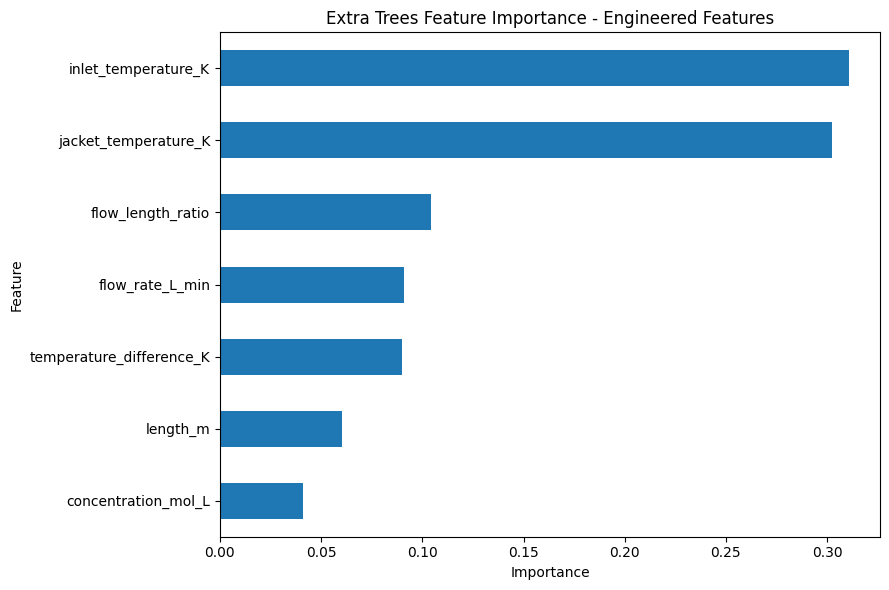

In [ ]:
plt.figure(figsize=(9, 6))

engineered_importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Extra Trees Feature Importance - Engineered Features")

plt.tight_layout()
plt.show()

In [ ]:
rf_fe_model = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    max_features=1.0
)

rf_fe_model.fit(
    train_fe,
    y_train_split
)

y_pred_rf_fe = rf_fe_model.predict(val_fe)

rmse_rf_fe = np.sqrt(
    mean_squared_error(y_val, y_pred_rf_fe)
)

print("Random Forest with engineered features RMSE:", rmse_rf_fe)

Random Forest with engineered features RMSE: 20.826590823452612


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=15,
    random_state=RANDOM_STATE
)

hgb_model.fit(
    train_fe,
    y_train_split
)

y_pred_hgb = hgb_model.predict(val_fe)

rmse_hgb = np.sqrt(
    mean_squared_error(y_val, y_pred_hgb)
)

print("HistGradientBoosting RMSE:", rmse_hgb)

HistGradientBoosting RMSE: 22.816740785715556


In [ ]:
engineered_search = RandomizedSearchCV(
    estimator=ExtraTreesRegressor(
        random_state=RANDOM_STATE
    ),
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

engineered_search.fit(
    train_fe,
    y_train_split
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=ExtraTreesRegressor(random_state=42), n_iter=30,
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 5, 8, 12, 16],
                                        'max_features': [1.0, 'sqrt', 0.8],
                                        'min_samples_leaf': [1, 2, 3, 4],
                                        'min_samples_split': [2, 3, 5, 8],
                                        'n_estimators': [200, 300, 500, 800]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [ ]:
print("Best Engineered CV RMSE:",
      -engineered_search.best_score_)

print("\nBest Parameters:")
print(engineered_search.best_params_)

Best Engineered CV RMSE: 19.028731564652357

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 12}


In [ ]:
best_engineered_model = engineered_search.best_estimator_

y_pred_best = best_engineered_model.predict(val_fe)

rmse_best = np.sqrt(
    mean_squared_error(y_val, y_pred_best)
)

print("Tuned Engineered Extra Trees Validation RMSE:", rmse_best)

Tuned Engineered Extra Trees Validation RMSE: 18.187811100085707


In [ ]:
test_fe = test_df[features].copy()

test_fe["temperature_difference_K"] = (
    test_fe["inlet_temperature_K"]
    - test_fe["jacket_temperature_K"]
)

test_fe["flow_length_ratio"] = (
    test_fe["flow_rate_L_min"]
    / test_fe["length_m"]
)

In [ ]:
print("Test engineered shape:", test_fe.shape)
print(test_fe.head())

Test engineered shape: (50, 7)
   flow_rate_L_min  concentration_mol_L  inlet_temperature_K  length_m  \
0            43.73                 2.88               454.18      7.66   
1            47.80                 2.33               401.37     19.95   
2             7.14                 0.65               411.86      3.05   
3            17.86                 1.28               385.97     22.36   
4            56.40                 2.51               495.33      8.36   

   jacket_temperature_K  temperature_difference_K  flow_length_ratio  
0                440.61                     13.57           5.708877  
1                390.13                     11.24           2.395990  
2                476.23                    -64.37           2.340984  
3                353.56                     32.41           0.798748  
4                517.71                    -22.38           6.746411  


In [ ]:
final_train = X_train.copy()

final_train["temperature_difference_K"] = (
    final_train["inlet_temperature_K"]
    - final_train["jacket_temperature_K"]
)

final_train["flow_length_ratio"] = (
    final_train["flow_rate_L_min"]
    / final_train["length_m"]
)

print("Final training shape:", final_train.shape)

Final training shape: (150, 7)


In [ ]:
final_model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    max_features=1.0
)

final_model.fit(
    final_train,
    Y_train
)

ExtraTreesRegressor(n_estimators=300, random_state=42)

In [ ]:
test_predictions = final_model.predict(test_fe)

print("Number of predictions:", len(test_predictions))
print(test_predictions[:10])

Number of predictions: 50
[22.85029333 79.06423333 26.20406667 86.00193667  1.02753667 54.57336
 83.48051333 65.52321     2.93929    56.37102333]


In [ ]:
print("Min prediction:", test_predictions.min())
print("Max prediction:", test_predictions.max())
print("Mean prediction:", test_predictions.mean())

print("\nNumber of predictions below 0:",
      (test_predictions < 0).sum())

print("Number of predictions above 100:",
      (test_predictions > 100).sum())

Min prediction: 0.1160566666666667
Max prediction: 87.24728666666664
Mean prediction: 29.68420633333335

Number of predictions below 0: 0
Number of predictions above 100: 0


In [ ]:
submission_predictions = np.round(test_predictions, 3)

print(submission_predictions)
print("Number of predictions:", len(submission_predictions))

[22.85  79.064 26.204 86.002  1.028 54.573 83.481 65.523  2.939 56.371
  0.289  0.219  5.454 51.054  3.743  0.36   2.813  5.484  3.763  2.283
 64.626  2.156  0.116 87.247 28.18  21.854 73.396 37.501 70.042  3.253
 69.336 60.407 47.217  1.478 25.979 16.063 14.743 55.715  0.197 53.35
  1.08  26.187  4.003  5.281 52.252 80.795  2.577  1.069 21.645  2.97 ]
Number of predictions: 50


In [ ]:
submission = pd.DataFrame({
    "overall_yield": submission_predictions
})

print(submission.head())
print("\nShape:", submission.shape)
print("\nColumns:", submission.columns.tolist())

   overall_yield
0         22.850
1         79.064
2         26.204
3         86.002
4          1.028

Shape: (50, 1)

Columns: ['overall_yield']


In [ ]:
assert len(submission) == 50
assert list(submission.columns) == ["overall_yield"]
assert submission["overall_yield"].dtype != "object"
assert submission["overall_yield"].notna().all()

print("✓ Exactly 50 rows")
print("✓ Exactly one column")
print("✓ Correct column name")
print("✓ No missing predictions")
print("✓ Predictions are numerical")

✓ Exactly 50 rows
✓ Exactly one column
✓ Correct column name
✓ No missing predictions
✓ Predictions are numerical


In [ ]:
TEAM_NAME = "Pekka"

submission.to_csv(
    f"{TEAM_NAME}.csv",
    index=False
)

print(f"Submission saved as: {TEAM_NAME}.csv")

Submission saved as: Pekka.csv


In [ ]:
check_submission = pd.read_csv(f"{TEAM_NAME}.csv")

print(check_submission.head())
print("\nShape:", check_submission.shape)
print("\nColumns:", check_submission.columns.tolist())

   overall_yield
0         22.850
1         79.064
2         26.204
3         86.002
4          1.028

Shape: (50, 1)

Columns: ['overall_yield']
